<a href="https://colab.research.google.com/github/pratheeth123/ML-LAB/blob/main/week9/Week_9_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

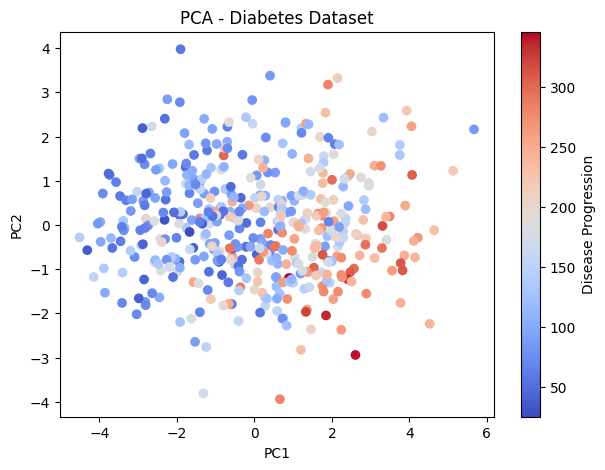

Explained Variance Ratio: [0.40242108 0.14923197]
Total Variance Captured: 0.5516530427751478
Eigenvalues: [4.03333594 1.49570362]
Mean of PCs: [-2.71276214e-17 -7.63592307e-17]
Variance of PCs: [4.02421075 1.49231968]
Reconstruction Error (MSE): 0.448346957224852


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# Load dataset
data = load_diabetes()
X = data.data
y = data.target

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA → 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(7,5))
sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Diabetes Dataset")
plt.colorbar(sc, label="Disease Progression")
plt.show()

# -------------------- NUMERICAL METRICS --------------------

# Explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Total variance captured
print("Total Variance Captured:", np.sum(pca.explained_variance_ratio_))

# Eigenvalues (variance of PCs)
print("Eigenvalues:", pca.explained_variance_)

# Mean of transformed data
print("Mean of PCs:", np.mean(X_pca, axis=0))

# Variance of transformed data
print("Variance of PCs:", np.var(X_pca, axis=0))

# Reconstruction (inverse transform)
X_reconstructed = pca.inverse_transform(X_pca)

# Reconstruction Error (MSE)
mse = mean_squared_error(X_scaled, X_reconstructed)
print("Reconstruction Error (MSE):", mse)